In [ ]:
-1.292,120.431,12,6.6
5/29/2017

In [1]:
import pandas as pd

In [512]:
df=pd.read_csv('nss_eq_batches.csv')

In [553]:
result_df.SEEN.max()

Timestamp('2021-08-30 14:52:59')

In [513]:
df.shape

(41701, 1)

In [427]:
df1.head()

,NS_ID,latitude,longitude,IP
0,102118381,-6.1781,106.63,45.126.56.42
1,102118384,-6.1781,106.63,45.126.56.42
2,102118387,-6.1781,106.63,45.126.56.42
3,102118452,-6.1781,106.63,45.126.56.42
4,102118485,-6.1781,106.63,45.126.56.42


In [148]:
df1=pd.read_csv('indo_ips_lat_lon.csv')

In [429]:
len(df1.NS_ID.unique())

38810

In [433]:
ns_ids=set(result_df.NS_ID.unique())

In [436]:
df1[df1['NS_ID'] is in ns_ids]

SyntaxError: invalid syntax (426549131.py, line 1)

In [437]:
filtered_df = df1[df1['NS_ID'].isin(ns_ids)]


In [442]:
df1=df1.drop_duplicates('IP')

In [583]:
filtered_df.to_csv("servers_with_loc_for_map.csv")

In [443]:
import folium
# Create a map centered on the average latitude and longitude
map_center = [df1['latitude'].mean(), df1['longitude'].mean()]
server_map = folium.Map(location=map_center, zoom_start=10)

# Add markers for each server
for _, row in filtered_df.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"NS_ID: {row['NS_ID']}<br>IP: {row['IP']}",
        tooltip=f"Server: {row['NS_ID']}",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(server_map)

# Save the map to an HTML file
server_map.save('server_map.html')

print("Map has been saved as 'server_map.html'")

Map has been saved as 'server_map.html'


In [378]:
df_nss=pd.read_csv('nss_eq_batches.csv', delimiter='\t')

In [439]:
len(df_nss.NS_ID.unique())

3476

In [382]:
df_nss.columns=df.columns

In [340]:
df1.head()

,NS_ID,latitude,longitude,IP
0,102118381,-6.1781,106.63,45.126.56.42
1,102118384,-6.1781,106.63,45.126.56.42
2,102118387,-6.1781,106.63,45.126.56.42
3,102118452,-6.1781,106.63,45.126.56.42
4,102118485,-6.1781,106.63,45.126.56.42


In [341]:
df1=df1[['NS_ID','latitude','longitude','IP']]

In [342]:
df1.head()

,NS_ID,latitude,longitude,IP
0,102118381,-6.1781,106.63,45.126.56.42
1,102118384,-6.1781,106.63,45.126.56.42
2,102118387,-6.1781,106.63,45.126.56.42
3,102118452,-6.1781,106.63,45.126.56.42
4,102118485,-6.1781,106.63,45.126.56.42


In [343]:
result_df = pd.merge(df_nss, df1, how='inner', on='NS_ID')

In [344]:
result_df.head()

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP
0,481422335,102627740,1509991429,NaN,0,0,0,NaN,0,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
1,587503169,102627740,1512471831,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
2,707498448,102627740,1515172274,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
3,818243968,102627740,1520870089,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
4,1149793611,102627740,1535896288,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66


In [17]:
result_df.to_csv('eq1_nss_loc.csv')

In [164]:
result_df['SEEN'] = pd.to_datetime(result_df['SEEN'], unit='s')

In [165]:
result_df.head()

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP
0,481422335,102627740,2017-11-06 18:03:49,NaN,0,0,0,NaN,0,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
1,587503169,102627740,2017-12-05 11:03:51,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
2,707498448,102627740,2018-01-05 17:11:14,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
3,818243968,102627740,2018-03-12 15:54:49,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
4,1149793611,102627740,2018-09-02 13:51:28,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66


In [166]:
len(result_df.NS_ID.unique())

3476

In [167]:
result_df.IS_ONLINE.value_counts()

IS_ONLINE
1    36069
0     5632
Name: count, dtype: int64

In [168]:
df_tsu=pd.read_csv('tsunamies.csv')

In [169]:
df_tsu.head()

,Year,Mo,Dy,Earthquake Magnitude,Vol,Location Name,Latitude,Longitude,Date_yyyy_mm_dd
0,2018,7,28,6.4,NaN,BALI SEA,-8.240,116.508,2018-07-28
1,2018,8,5,6.9,NaN,BALI SEA,-8.258,116.438,2018-08-05
2,2018,8,19,6.3,NaN,BALI SEA,-8.337,116.599,2018-08-19
3,2018,9,28,7.5,NaN,SULAWESI,-0.256,119.846,2018-09-28
4,2018,12,22,NaN,7264.0,KRAKATAU,-6.102,105.423,2018-12-22


In [176]:
df_tsu.shape

(12, 10)

In [175]:
df_tsu.Vol.isna().sum()

np.int64(10)

In [170]:
df_eq=pd.read_csv('earthquakes.csv')

In [171]:
df_eq.head()

,INDEX,Latitude,Longitude,Focal Depth (km),Mag,Date
0,0,-8.492,115.323,112.0,5.6,3/21/2017
1,1,-1.292,120.431,12.0,6.6,5/29/2017
2,2,-3.745,127.752,6.0,6.1,10/31/2017
3,3,2.465,128.148,8.0,5.8,11/18/2017
4,4,-7.492,108.174,90.0,6.5,12/15/2017


In [ ]:
import pandas as pd


df_eq['Disaster_Type'] = 'Earthquake'
df_tsu['Disaster_Type'] = 'Tsunami'


earthquake_columns = df_eq[['Latitude', 'Longitude', 'Disaster_Type', 'Date', 'Mag']]
tsunami_columns = df_tsu[['Latitude', 'Longitude', 'Disaster_Type', 'Date_yyyy_mm_dd', 'Earthquake Magnitude']]


earthquake_columns.rename(columns={'Mag': 'Magnitude', 'Date': 'Date'}, inplace=True)
tsunami_columns.rename(columns={'Earthquake Magnitude': 'Magnitude', 'Date_yyyy_mm_dd': 'Date'}, inplace=True)


combined_df = pd.concat([earthquake_columns, tsunami_columns], ignore_index=True)


print(combined_df.head())


combined_df.to_csv('combined_disasters.csv', index=False)


   Latitude  Longitude Disaster_Type        Date  Magnitude
0    -8.492    115.323    Earthquake   3/21/2017        5.6
1    -1.292    120.431    Earthquake   5/29/2017        6.6
2    -3.745    127.752    Earthquake  10/31/2017        6.1
3     2.465    128.148    Earthquake  11/18/2017        5.8
4    -7.492    108.174    Earthquake  12/15/2017        6.5


C:\Users\gokul\AppData\Local\Temp\ipykernel_49856\1242802623.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  earthquake_columns.rename(columns={'Mag': 'Magnitude', 'Date': 'Date'}, inplace=True)
C:\Users\gokul\AppData\Local\Temp\ipykernel_49856\1242802623.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tsunami_columns.rename(columns={'Earthquake Magnitude': 'Magnitude', 'Date_yyyy_mm_dd': 'Date'}, inplace=True)


In [548]:
df_eq.head()

,INDEX,Latitude,Longitude,Focal Depth (km),Mag,Date,Disaster_Type
0,0,-8.492,115.323,112.0,5.6,3/21/2017,Earthquake
1,1,-1.292,120.431,12.0,6.6,5/29/2017,Earthquake
2,2,-3.745,127.752,6.0,6.1,10/31/2017,Earthquake
3,3,2.465,128.148,8.0,5.8,11/18/2017,Earthquake
4,4,-7.492,108.174,90.0,6.5,12/15/2017,Earthquake


In [ ]:
import folium
import pandas as pd



earthquake_map = folium.Map(location=[-2.5, 118.0], zoom_start=5)
df_eq['Date'] = pd.to_datetime(df_eq['Date']) 

for _, row in df_eq.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=row['Mag'] * 2,  
        color='red',
        fill=True,
        fill_opacity=0.7,
        popup=(
            f"Date: {row['Date'].date()}<br>"
            f"Magnitude: {row['Mag']}<br>"
            f"Index: {row['INDEX']} km<br>"
            f"Location: ({row['Latitude']}, {row['Longitude']})"
        ),
        tooltip=f"Magnitude: {row['Mag']}",
    ).add_to(earthquake_map)

# Save the map to an HTML file
earthquake_map.save('earthquake_map.html')
print("Earthquake map saved as 'earthquake_map.html'")


Earthquake map saved as 'earthquake_map.html'


In [178]:
combined_df=combined_df.dropna()

In [179]:
combined_df.shape

(55, 5)

In [ ]:
import pandas as pd




quake_time = pd.Timestamp('2017-05-29')

# Define the 30-day window
start_time = quake_time - pd.Timedelta(days=40)
end_time = quake_time + pd.Timedelta(days=20)

# Filter the data within the 30-day time frame
filtered_data = result_df[(result_df['SEEN'] >= start_time) & (result_df['SEEN'] <= end_time)]

filtered_data.head()

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude
12290,42265702,30557907,2017-06-17 06:45:14,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2611,107.1528
12301,42265706,30557911,2017-06-17 06:45:14,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2611,107.1528
12312,42265710,30557915,2017-06-17 06:45:14,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2611,107.1528
12323,42265720,30557925,2017-06-17 06:45:14,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2611,107.1528
12334,42265851,30558054,2017-06-17 06:45:16,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2611,107.1528


In [89]:
result_df.SEEN.min()

Timestamp('2017-06-16 07:19:09')

In [88]:
filtered_data.IS_ONLINE.value_counts()

IS_ONLINE
1    87
0    40
Name: count, dtype: int64

In [119]:
result_df.SEEN.min()

Timestamp('2017-06-16 07:19:09')

In [123]:
!pip install ace_tools

In [126]:
sorted_df = result_df.sort_values(by=['NS_ID', 'SEEN'])

# Display the sorted DataFrame interactively for scrolling
import ace_tools as tools;
tools.display_dataframe_to_user(name="Sorted Data by NS_ID and SEEN", dataframe=sorted_df)

ModuleNotFoundError: No module named 'ace_tools'

In [127]:
from IPython.display import display

# Display the DataFrame interactively
display(sorted_df)


,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,IP
40336,15966193,9866985,NaT,NaN,1,1,2017060604,Norlec NS2 Server,1,1,1,3,3,3,43.240.227.18
40337,18454633,9866985,NaT,NaN,1,1,2017060616,Norlec NS2 Server,1,1,1,3,3,3,43.240.227.18
40338,161195339,9866985,NaT,NaN,1,1,2017061406,NaN,1,1,1,3,3,3,43.240.227.18
40339,253638413,9866985,NaT,NaN,1,1,0,NaN,1,0,0,2,2,3,43.240.227.18
40340,348505585,9866985,NaT,NaN,1,1,0,NaN,1,0,0,2,2,3,43.240.227.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40814,1732996906,156429164,NaT,NaN,1,1,0,NaN,1,0,0,2,2,2,45.114.118.138
40815,1774286762,156429164,NaT,NaN,1,1,0,NaN,1,0,0,2,2,2,45.114.118.138
40816,1842756601,156429164,NaT,NaN,1,1,0,NaN,1,0,0,2,2,2,45.114.118.138
40817,1055170568,156429166,NaT,NaN,1,1,0,NaN,1,0,0,2,2,2,45.114.118.138


In [131]:
# Count NaT values for each NS_ID
nat_counts = df['SEEN'].isna().sum()

# Count non-NaT values for each NS_ID
not_nat_counts = (~df['SEEN'].isna()).sum()

print(f"Total NaT values: {nat_counts}")
print(f"Total Not NaT values: {not_nat_counts}")



Total NaT values: 8599
Total Not NaT values: 33102


Date with the most servers going offline: 2018-01-05
Number of servers going offline on that date: 47


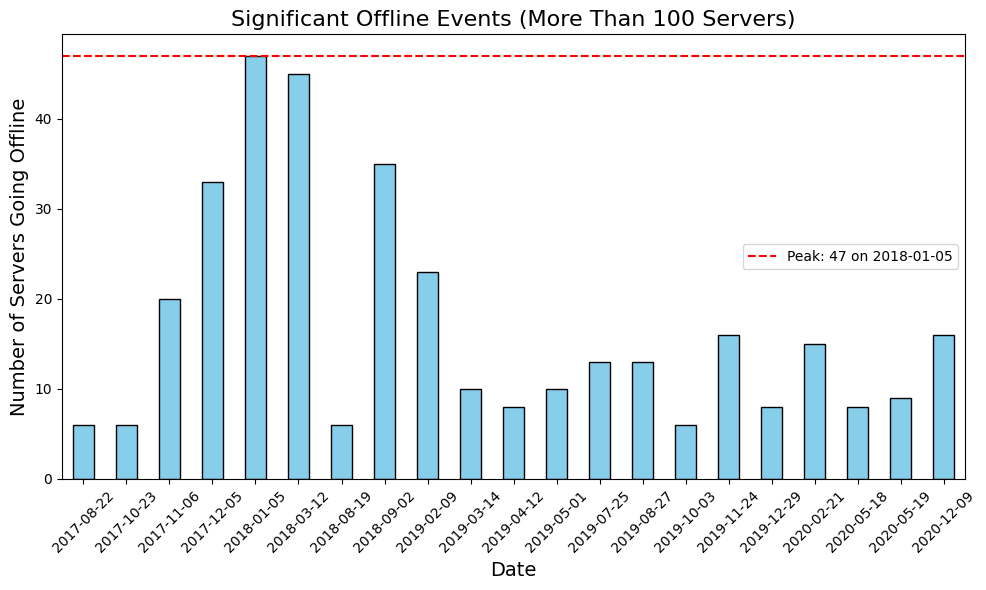

In [155]:
import pandas as pd
import matplotlib.pyplot as plt



# Sort data by NS_ID and timestamp
df = result_df.sort_values(by=['NS_ID', 'SEEN'])

# Identify servers that went offline
df['Went_Offline'] = (df['IS_ONLINE'] == 0) & (df['IS_ONLINE'].shift(1) == 1) & (df['NS_ID'] == df['NS_ID'].shift(1))

# Filter the rows where servers went offline
offline_events = df[df['Went_Offline']].copy()

# Extract dates and group by date to count offline events
offline_events['Offline_Date'] = offline_events['SEEN'].dt.date
offline_count_by_date = offline_events.groupby('Offline_Date').size()

# Filter dates where the offline count exceeds 100
significant_offline_counts = offline_count_by_date[offline_count_by_date > 5]

# Plot only if there are significant offline events
if not significant_offline_counts.empty:
    most_offline_date = significant_offline_counts.idxmax()
    most_offline_count = significant_offline_counts.max()

    print(f"Date with the most servers going offline: {most_offline_date}")
    print(f"Number of servers going offline on that date: {most_offline_count}")

    # Plot the trend of servers going offline by date
    plt.figure(figsize=(10, 6))
    significant_offline_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Significant Offline Events (More Than 100 Servers)', fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Number of Servers Going Offline', fontsize=14)
    plt.axhline(y=most_offline_count, color='red', linestyle='--', label=f"Peak: {most_offline_count} on {most_offline_date}")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No dates found where more than 10 servers went offline.")


In [262]:
plot_df= result_df[(result_df['SEEN']==pd.to_datetime('2018-01-05')) & result_df['IS_ONLINE']==0]

In [266]:
!pip install plotly

   ---------------------------------------- 0.0/19.1 MB ? eta -:--:--
   - -------------------------------------- 0.8/19.1 MB 6.7 MB/s eta 0:00:03
   ------- -------------------------------- 3.4/19.1 MB 11.2 MB/s eta 0:00:02
   ------------- -------------------------- 6.6/19.1 MB 12.6 MB/s eta 0:00:01
   ------------------ --------------------- 8.9/19.1 MB 11.8 MB/s eta 0:00:01
   ------------------------ --------------- 11.8/19.1 MB 12.1 MB/s eta 0:00:01
   ------------------------------ --------- 14.7/19.1 MB 12.5 MB/s eta 0:00:01
   ----------------------------------- ---- 16.8/19.1 MB 12.0 MB/s eta 0:00:01
   ---------------------------------------- 19.1/19.1 MB 11.9 MB/s eta 0:00:00


In [265]:
import plotly.express as px

# Aggregate data: Sum NS_ID for each (latitude, longitude)
aggregated_data = plot_df.groupby(['latitude', 'longitude']).agg({'NS_ID': 'sum'}).reset_index()

# Create a bubble map
fig = px.scatter_mapbox(
    aggregated_data,
    lat="latitude",
    lon="longitude",
    size="NS_ID",  # Bubble size based on NS_ID sum
    title="Indonesia Map with Bubble Size Equal to Sum of NS_ID",
    size_max=30,  # Maximum bubble size
    zoom=5,
    height=600
)

# Set map style and center
fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_zoom=5,
    mapbox_center={"lat": -2.5, "lon": 117.5}  # Centering the map around Indonesia
)

# Show the plot
fig.show()


ModuleNotFoundError: No module named 'plotly'

In [345]:
import pandas as pd

# Example Server Data



df = result_df.sort_values(by=['NS_ID', 'SEEN'])


# Identify servers that went offline and then came back online
df['Went_Offline'] = (
    (df['IS_ONLINE'] == 0) &
    (df['IS_ONLINE'].shift(1) == 1) &
    (df['NS_ID'] == df['NS_ID'].shift(1))
)

df['Came_Back_Online'] = (
    (df['IS_ONLINE'] == 1) &
    (df['IS_ONLINE'].shift(1) == 0) &
    (df['NS_ID'] == df['NS_ID'].shift(1))
)

# Filter servers that went offline and came back online
offline_to_online = df[(df['Went_Offline'] | df['Came_Back_Online'])]

# Display the results
print("Servers that went offline and came back online:")
print(offline_to_online.head())


Servers that went offline and came back online:
               ID     NS_ID        SEEN  AVG_RTT_MILLIS  IS_ONLINE  IS_AUTH  \
40351   348507077   9866994  1506402338             NaN          0        0   
40352   441311026   9866994  1509084767             NaN          1        1   
40360   348507081   9866996  1506402338             NaN          0        0   
40361   441310917   9866996  1509084763             NaN          1        1   
25955  1441011547  30017237  1555766912             NaN          0        0   

       SERIAL VERSION  EDNS0  CNAME  BOGUS  VALID_SOA  KEYS_VERIF  \
40351       0     NaN      0      0      0          2           2   
40352       0     NaN      1      0      0          2           2   
40360       0     NaN      0      0      0          2           2   
40361       0     NaN      1      0      0          2           2   
25955       0     NaN      0      0      0          2           2   

       FOUND_WHERE  latitude  longitude               IP  Went

In [216]:
offline_to_online[offline_to_online.Came_Back_Online
==True].NS_ID.value_counts()

NS_ID
101974198    4
62673976     4
101974201    4
102626298    4
101923817    3
            ..
35263425     1
35263441     1
35263444     1
38715095     1
44226289     1
Name: count, Length: 368, dtype: int64

In [211]:
result_df[result_df['NS_ID']==101974198]

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP
27865,379288207,101974198,2017-10-08 19:19:15,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2146,106.8451,182.23.94.119
27866,586547758,101974198,2017-12-05 05:47:43,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.2146,106.8451,182.23.94.119
27867,706661120,101974198,2018-01-05 11:55:12,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.2146,106.8451,182.23.94.119
27868,817529349,101974198,2018-03-12 09:42:52,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2146,106.8451,182.23.94.119
27869,1149329050,101974198,2018-09-02 09:36:33,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.2146,106.8451,182.23.94.119
27870,1305853002,101974198,2019-02-09 02:58:53,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.2146,106.8451,182.23.94.119
27871,1362775337,101974198,2019-03-14 16:05:21,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.2146,106.8451,182.23.94.119
27872,1423872013,101974198,2019-04-12 20:49:11,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2146,106.8451,182.23.94.119
27873,1472804487,101974198,2019-05-01 07:23:19,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.2146,106.8451,182.23.94.119
27874,1569670327,101974198,2019-06-18 02:30:51,NaN,1,0,0,NaN,1,0,0,2,2,3,-6.2146,106.8451,182.23.94.119


In [186]:
disasters.head()

,Latitude,Longitude,Disaster_Type,Date,Magnitude
0,-8.492,115.323,Earthquake,2017-03-21,5.6
1,-1.292,120.431,Earthquake,2017-05-29,6.6
2,-3.745,127.752,Earthquake,2017-10-31,6.1
3,2.465,128.148,Earthquake,2017-11-18,5.8
4,-7.492,108.174,Earthquake,2017-12-15,6.5


In [187]:
servers.head()

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP
0,481422335,102627740,2017-11-06 18:03:49,NaN,0,0,0,NaN,0,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
1,587503169,102627740,2017-12-05 11:03:51,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
2,707498448,102627740,2018-01-05 17:11:14,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
3,818243968,102627740,2018-03-12 15:54:49,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
4,1149793611,102627740,2018-09-02 13:51:28,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66


In [198]:
import pandas as pd
from geopy.distance import geodesic

# Use the combined disaster and server datasets
disasters = combined_df
servers = result_df

# Parse disaster dates with mixed formats
disasters['Date'] = pd.to_datetime(disasters['Date'], errors='coerce')

# Identify rows with invalid dates and drop them
invalid_dates = disasters[disasters['Date'].isna()]
print("Invalid Dates Detected:")
print(invalid_dates)
disasters = disasters.dropna(subset=['Date'])

# Parse server timestamps
servers['SEEN'] = pd.to_datetime(servers['SEEN'])

# Sort servers by NS_ID and SEEN
servers = servers.sort_values(by=['NS_ID', 'SEEN'])

# Define proximity threshold (in km) and time window (e.g., ±20 days)
proximity_threshold = 100  # km
time_window = pd.Timedelta(days=20)

# Identify servers that went offline
servers['Went_Offline'] = (
    (servers['IS_ONLINE'] == 0) &
    (servers['IS_ONLINE'].shift(1) == 1) &
    (servers['NS_ID'] == servers['NS_ID'].shift(1))
)

# Collect results for servers impacted by disasters
results = []

for _, disaster in disasters.iterrows():
    disaster_location = (disaster['Latitude'], disaster['Longitude'])
    disaster_date = disaster['Date']
    
    # Filter servers within proximity
    for _, server in servers.iterrows():
        server_location = (server['latitude'], server['longitude'])
        distance = geodesic(disaster_location, server_location).km
        
        if distance <= proximity_threshold:
            # Check if the server's status changed during the disaster
            went_offline_during_disaster = (
                (server['SEEN'] >= disaster_date - time_window) &
                (server['SEEN'] <= disaster_date + time_window) &
                (server['Went_Offline'])
            )
            
            stayed_online_during_disaster = (
                (server['SEEN'] >= disaster_date - time_window) &
                (server['SEEN'] <= disaster_date + time_window) &
                (server['IS_ONLINE'] == 1)
            )
            
            # Add results based on status
            if went_offline_during_disaster:
                results.append({
                    'server_id': server['NS_ID'],
                    'disaster_type': disaster['Disaster_Type'],
                    'disaster_date': disaster['Date'],
                    'distance_km': distance,
                    'status_change': 'Went Offline'
                })
            elif stayed_online_during_disaster:
                results.append({
                    'server_id': server['NS_ID'],
                    'disaster_type': disaster['Disaster_Type'],
                    'disaster_date': disaster['Date'],
                    'distance_km': distance,
                    'status_change': 'Stayed Online'
                })

# Convert results to a DataFrame
disaster_impact_df = pd.DataFrame(results)

# Display the results
print(disaster_impact_df)

# Save results to a CSV file for further analysis
disaster_impact_df.to_csv('disaster_server_status_sorted.csv', index=False)


Invalid Dates Detected:
    Latitude  Longitude Disaster_Type Date  Magnitude
46    -8.240    116.508       Tsunami  NaT        6.4
47    -8.258    116.438       Tsunami  NaT        6.9
48    -8.337    116.599       Tsunami  NaT        6.3
49    -0.256    119.846       Tsunami  NaT        7.5
51    -7.282    104.791       Tsunami  NaT        6.9
52     1.600    126.416       Tsunami  NaT        7.1
54    -3.593    129.503       Tsunami  NaT        5.8
55    -7.603    122.200       Tsunami  NaT        7.3
56    -7.049    130.038       Tsunami  NaT        7.6
57    -0.799     98.524       Tsunami  NaT        7.1
     server_id disaster_type disaster_date  distance_km  status_change
0     83050948    Earthquake    2017-12-15    75.606734  Stayed Online
1     83050948    Earthquake    2017-12-15    75.606734  Stayed Online
2     83051035    Earthquake    2017-12-15    75.606734  Stayed Online
3     83051035    Earthquake    2017-12-15    75.606734  Stayed Online
4     83051083    Earthquak

In [202]:
disaster_impact_df[disaster_impact_df['status_change']=='Went Offline']

,server_id,disaster_type,disaster_date,distance_km,status_change
14,83554781,Earthquake,2017-12-15,88.847474,Went Offline
24,97599618,Earthquake,2017-12-15,88.847474,Went Offline
26,97599641,Earthquake,2017-12-15,88.847474,Went Offline
28,97599661,Earthquake,2017-12-15,88.847474,Went Offline
30,97599749,Earthquake,2017-12-15,88.847474,Went Offline
96,109300545,Earthquake,2017-12-15,75.606734,Went Offline
240,62673726,Earthquake,2020-03-10,68.236570,Went Offline
248,62673763,Earthquake,2020-03-10,68.236570,Went Offline
256,62673976,Earthquake,2020-03-10,68.236570,Went Offline
264,62674078,Earthquake,2020-03-10,68.236570,Went Offline


In [ ]:
import pandas as pd
import folium
from datetime import datetime, timedelta


df=result_df

df['SEEN'] = pd.to_datetime(df['SEEN'], unit='s')


earthquake_date = datetime(2017, 5, 29)
ten_day_window = earthquake_date + timedelta(days=20)


df['Went_Offline'] = (df['IS_ONLINE'] == 0) & (df['SEEN'] >= earthquake_date) & (df['SEEN'] <= ten_day_window)


offline_servers = df[df['Went_Offline']].copy()


offline_servers['Offline_After_Hours'] = (offline_servers['SEEN'] - earthquake_date).dt.total_seconds() / 3600


print("Servers that went offline after the earthquake:")
print(offline_servers[['NS_ID', 'SEEN', 'Offline_After_Hours']])



Servers that went offline after the earthquake:
          NS_ID                SEEN  Offline_After_Hours
36894  30848630 2017-06-17 09:22:58           465.382778
36910  30848638 2017-06-17 09:22:58           465.382778
36923  30848664 2017-06-17 09:22:59           465.383056
36939  30848672 2017-06-17 09:22:59           465.383056


In [50]:
len(result_df.latitude.unique())

17

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,Went_Offline
128,380294775,102896015,2017-10-09 03:07:43,NaN,0,0,0,NaN,0,0,0,2,2,1,False
133,380294855,102896077,2017-10-09 03:07:45,NaN,0,0,0,NaN,0,0,0,2,2,1,False
138,380294860,102896082,2017-10-09 03:07:45,NaN,0,0,0,NaN,0,0,0,2,2,1,False
143,380294865,102896087,2017-10-09 03:07:45,NaN,0,0,0,NaN,0,0,0,2,2,1,False
148,380294870,102896092,2017-10-09 03:07:45,NaN,0,0,0,NaN,0,0,0,2,2,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33030,169369669,67251398,2017-07-30 22:06:37,NaN,0,0,0,NaN,0,0,0,2,2,3,False
33031,261646491,67251398,2017-08-30 08:21:46,NaN,0,0,0,NaN,0,0,0,2,2,3,False
33032,169369734,67251463,2017-07-30 22:06:40,NaN,0,0,0,NaN,0,0,0,2,2,3,False
33033,261646629,67251463,2017-08-30 08:21:49,NaN,0,0,0,NaN,0,0,0,2,2,3,False


(28808, 15)

In [ ]:
from geopy.distance import geodesic

epicenter = (-7.492  , 108.174)

def is_within_radius(lat, lon, center, radius_km=100):
    return geodesic((lat, lon), center).km <= radius_km


area_filtered_df = result_df[
    result_df.apply(lambda row: is_within_radius(row['latitude'], row['longitude'], epicenter), axis=1)
]


In [350]:
result_df.shape

(41701, 17)

In [351]:
result_df.head()

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP
0,481422335,102627740,2017-11-06 18:03:49,NaN,0,0,0,NaN,0,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
1,587503169,102627740,2017-12-05 11:03:51,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
2,707498448,102627740,2018-01-05 17:11:14,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
3,818243968,102627740,2018-03-12 15:54:49,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66
4,1149793611,102627740,2018-09-02 13:51:28,NaN,1,1,0,NaN,1,0,0,2,2,3,-7.7625,110.4317,101.203.168.66


In [349]:
result_df['SEEN']=pd.to_datetime(result_df['SEEN'],unit='s')

In [532]:
result_df.NS_ID.unique()

array([102627740, 102627745, 102627752, ...,  97601432,  97601443,
        97601445])

In [535]:
result_df[result_df.NS_ID==97601445].head(10)

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP
41679,290755410,97601445,2017-09-08 11:27:58,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,60.253.96.40
41680,379004491,97601445,2017-10-08 17:26:10,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,60.253.96.40
41681,480492786,97601445,2017-11-06 10:26:40,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,60.253.96.40
41682,586159639,97601445,2017-12-05 03:46:52,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,60.253.96.40
41683,706243804,97601445,2018-01-05 09:46:16,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,60.253.96.40
41684,817150478,97601445,2018-03-12 07:08:06,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,60.253.96.40
41685,1149117366,97601445,2018-09-02 07:48:47,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,60.253.96.40
41686,1305702248,97601445,2019-02-09 01:47:56,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,60.253.96.40
41687,1362625780,97601445,2019-03-14 14:39:00,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,60.253.96.40
41688,1423712150,97601445,2019-04-12 19:44:13,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,60.253.96.40


In [ ]:
from datetime import datetime, timedelta


start_time = datetime.strptime("2019-08-02 00:00:00", "%Y-%m-%d %H:%M:%S")
end_time = datetime.strptime("2019-09-10 23:59:59", "%Y-%m-%d %H:%M:%S")



time_filtered_df = result_df[(result_df['SEEN'] >= start_time-timedelta(10)) & 
                             (result_df['SEEN'] <= end_time)]

In [555]:
result_df.shape

(41701, 17)

In [556]:
time_filtered_df.IP.unique()

array(['101.50.2.3', '103.11.134.188', '103.11.134.190', '103.12.84.137',
       '103.13.181.24', '103.14.44.44', '103.15.242.58', '103.15.242.59',
       '103.16.199.69', '103.17.76.2', '103.17.76.8', '103.18.78.1',
       '103.18.79.1', '103.19.177.177', '103.19.178.178',
       '103.19.179.179', '103.19.180.193', '103.19.180.213',
       '103.195.142.3', '103.195.142.4', '103.195.30.250', '103.195.90.6',
       '103.198.131.2', '103.203.76.66', '103.203.76.67', '103.203.76.68',
       '103.203.77.69', '103.219.197.41', '103.219.6.1', '103.226.218.1',
       '103.23.100.9', '103.23.102.12', '103.23.116.40', '103.23.116.71',
       '103.23.21.120', '103.23.21.201', '103.23.22.162',
       '103.23.244.226', '103.233.100.4', '103.233.100.5',
       '103.233.144.151', '103.233.146.3', '103.235.34.46',
       '103.236.192.5', '103.236.192.6', '103.236.192.7',
       '103.239.165.34', '103.239.165.50', '103.24.48.1', '103.24.48.2',
       '103.241.179.250', '103.241.179.254', '103.242.233.

In [ ]:
import pandas as pd


df = time_filtered_df.sort_values(by=['NS_ID', 'SEEN'])


def process_group(group):
    group = group.sort_values(by='SEEN') 
    group['Went_Offline'] = (
        (group['IS_ONLINE'] == 0) &
        (group['IS_ONLINE'].shift(1) == 1)
    )
    group['Came_Back_Online'] = (
        (group['IS_ONLINE'] == 1) &
        (group['IS_ONLINE'].shift(1) == 0)
    )
    return group


processed_df = df.groupby('NS_ID').apply(process_group)


offline_to_online = processed_df[(processed_df['Went_Offline'] | processed_df['Came_Back_Online'])]


print("Servers that went offline and came back online:")
print(offline_to_online)


Servers that went offline and came back online:
                         ID      NS_ID                SEEN  AVG_RTT_MILLIS  \
NS_ID                                                                        
30464830  26724  1709074633   30464830 2019-09-05 15:09:02             NaN   
34368558  13443  1711014193   34368558 2019-09-06 11:14:55             NaN   
49708614  14208  1720109968   49708614 2019-09-10 20:28:23             NaN   
57534618  2495   1628041411   57534618 2019-07-31 00:09:52             NaN   
          2496   1638026643   57534618 2019-08-04 15:46:14             NaN   
57534622  2723   1628041315   57534622 2019-07-31 00:09:47             NaN   
          2724   1638026282   57534622 2019-08-04 15:45:43             NaN   
57534626  3032   1628041220   57534626 2019-07-31 00:09:42             NaN   
          3033   1638026010   57534626 2019-08-04 15:45:33             NaN   
101974198 27876  1689195898  101974198 2019-08-27 13:31:47             NaN   
101974201 27896 

C:\Users\gokul\AppData\Local\Temp\ipykernel_49856\1286748932.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  processed_df = df.groupby('NS_ID').apply(process_group)


In [558]:
processed_df[processed_df.Went_Offline==True]

,,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP,Went_Offline,Came_Back_Online
NS_ID,,,,,,,,,,,,,,,,,,,,
57534618,2495,1628041411,57534618,2019-07-31 00:09:52,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2146,106.8451,103.19.178.178,True,False
57534622,2723,1628041315,57534622,2019-07-31 00:09:47,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2146,106.8451,103.19.178.178,True,False
57534626,3032,1628041220,57534626,2019-07-31 00:09:42,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2146,106.8451,103.19.178.178,True,False
101974198,27876,1689195898,101974198,2019-08-27 13:31:47,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2146,106.8451,182.23.94.119,True,False
101974201,27896,1689195917,101974201,2019-08-27 13:31:47,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2146,106.8451,182.23.94.119,True,False
102175384,27746,1689321561,102175384,2019-08-27 14:30:34,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2146,106.8451,182.23.34.195,True,False
102175387,27766,1689320390,102175387,2019-08-27 14:30:01,NaN,0,0,0,NaN,0,0,0,2,2,3,-6.2146,106.8451,182.23.34.195,True,False
102626298,6177,1689598863,102626298,2019-08-27 16:38:58,NaN,0,0,0,NaN,0,0,0,2,2,3,-2.0561,101.3913,103.23.100.9,True,False
106082769,33101,1689191958,106082769,2019-08-27 13:30:04,NaN,0,0,0,NaN,0,0,0,2,2,2,-6.2146,106.8451,202.43.178.244,True,False


In [559]:
offline_servers=processed_df[processed_df['Went_Offline']==True]

In [560]:
len(offline_servers.NS_ID.unique())

16

In [581]:
result_df.SEEN.max()

Timestamp('2021-08-30 14:52:59')

In [562]:
len(offline_servers.IP.unique())

7

In [ ]:
processed_df=processed_df

ID    NS_ID                SEEN  AVG_RTT_MILLIS  \
NS_ID                                                                    
9866985 40346  1043116232  9866985 2018-07-10 14:26:07             NaN   
        40347  1121974277  9866985 2018-08-18 02:45:27             NaN   
9866996 40366  1043116401  9866996 2018-07-10 14:26:12             NaN   
        40367  1121974336  9866996 2018-08-18 02:45:34             NaN   
9867019 40376  1043116220  9867019 2018-07-10 14:26:07             NaN   

               IS_ONLINE  IS_AUTH  SERIAL VERSION  EDNS0  CNAME  BOGUS  \
NS_ID                                                                    
9866985 40346          1        1       0     NaN      1      0      0   
        40347          1        1       0     NaN      1      0      0   
9866996 40366          1        1       0     NaN      1      0      0   
        40367          1        1       0     NaN      1      0      0   
9867019 40376          1        1       0     NaN      1      0      0   

               VALID_SOA  KEYS_VERIF  FOUND_WHERE  latitude  longitude  \
NS_ID                                                                    
9866985 40346          2           2            3   -6.5924    110.671   
        40347          2           2            3   -6.5924    110.671   
9866996 40366          2           2            3   -6.5924    110.671   
        40367          2           2            3   -6.5924    110.671   
9867019 40376          2           2            3   -6.5924    110.671   

                          IP  Went_Offline  Came_Back_Online  
NS_ID                                                         
9866985 40346  43.240.227.18         False             False  
        40347  43.240.227.18         False             False  
9866996 40366  43.240.227.18         False             False  
        40367  43.240.227.18         False             False  
9867019 40376  43.240.227.18         False             False

In [563]:
online_servers=processed_df[(processed_df['Went_Offline']==False) & (processed_df['Came_Back_Online']==False) & (processed_df['IS_ONLINE']==True)]

In [564]:
offline_servers.IP.unique()

array(['103.19.178.178', '182.23.94.119', '182.23.34.195', '103.23.100.9',
       '202.43.178.244', '103.26.14.14', '119.235.26.35'], dtype=object)

In [565]:
online_servers=online_servers.reset_index(drop=True)

In [ ]:

online_servers_sorted = online_servers.sort_values(by=['NS_ID', 'SEEN'], ascending=[True, False])


latest_online_servers = online_servers_sorted.groupby('NS_ID').first().reset_index()


print("Latest instances of each NS_ID in online servers:")
print(latest_online_servers)


Latest instances of each NS_ID in online servers:
         NS_ID          ID                SEEN  AVG_RTT_MILLIS  IS_ONLINE  \
0      9867019  1667487243 2019-08-17 03:55:47             NaN          1   
1     28046708  1707550523 2019-09-04 23:33:12             NaN          1   
2     28046709  1707550524 2019-09-04 23:33:12             NaN          1   
3     28046710  1707550525 2019-09-04 23:33:12             NaN          1   
4     28046717  1707550634 2019-09-04 23:33:15             NaN          1   
..         ...         ...                 ...             ...        ...   
778  133708839  1687639138 2019-08-27 00:36:16             NaN          1   
779  133708840  1687639139 2019-08-27 00:36:16             NaN          1   
780  156429115  1675438910 2019-08-20 22:50:07             NaN          1   
781  156429162  1675439049 2019-08-20 22:50:12             NaN          1   
782  156429164  1675439087 2019-08-20 22:50:12             NaN          1   

     IS_AUTH  SERIAL VERS

,latitude,longitude,ns_count,ip_list
0,-7.4478,112.7183,3,"102615564, 102615604, 102615606"
1,-6.9222,107.6069,4,"97599616, 97599639, 97599659, 97599747"
2,-6.4000,106.8186,2,"106432027, 106432028"
3,-6.2886,106.7179,1,117038442
4,-6.2146,106.8451,10,"97652820, 97652821, 109254358, 109254383, 1092..."
5,-0.0319,109.3250,4,"102178064, 102178069, 102178169, 102178179"
6,0.5375,123.0625,4,"109368470, 109368473, 109368476, 109368479"


In [567]:
online_servers.SEEN.max()

Timestamp('2019-09-10 20:40:42')

In [ ]:
latest_online_servers.NS_ID==9867019

,NS_ID,ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP,Went_Offline,Came_Back_Online
0,9867019,1667487243,2019-08-17 03:55:47,NaN,1,1,0,None,1,0,0,2,2,3,-6.5924,110.6710,43.240.227.18,False,False
1,28046708,1707550523,2019-09-04 23:33:12,NaN,1,1,0,None,1,0,0,2,2,3,-6.2146,106.8451,202.137.3.120,False,False
2,28046709,1707550524,2019-09-04 23:33:12,NaN,1,1,0,None,1,0,0,2,2,3,-6.2146,106.8451,202.137.3.121,False,False
3,28046710,1707550525,2019-09-04 23:33:12,NaN,1,1,0,None,1,0,0,2,2,3,-6.2349,106.9896,202.73.99.8,False,False
4,28046717,1707550634,2019-09-04 23:33:15,NaN,1,1,0,None,1,0,0,2,2,3,-6.2146,106.8451,202.137.3.120,False,False


In [324]:
latest_online_servers.dropna(subset=['latitude', 'longitude'],inplace=True)

In [569]:
latest_online_servers.shape

(783, 19)

In [544]:
offline_servers.shape

(9, 19)

In [570]:
offline_ns_ids = set(offline_servers['NS_ID'])
filtered_online_servers = latest_online_servers[~online_servers['NS_ID'].isin(offline_ns_ids)]



C:\Users\gokul\AppData\Local\Temp\ipykernel_49856\2847773687.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_online_servers = latest_online_servers[~online_servers['NS_ID'].isin(offline_ns_ids)]


In [571]:
earthquake_date = pd.Timestamp('2019-08-02')
filtered_online_servers = filtered_online_servers[
    (filtered_online_servers['SEEN'] >= (earthquake_date)) 
]

In [572]:
import folium

# Create a map for offline servers
offline_map = folium.Map(location=[offline_servers['latitude'].mean(), offline_servers['longitude'].mean()], zoom_start=7)
earthquake_location = [-7.282,104.791]
# Add offline servers to the offline map
for _, row in offline_servers.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='red',
        fill=True,
        fill_opacity=0.6,
        tooltip=f"NS_ID: {row['NS_ID']}<br>IP: {row['IP']}<br>Status: Offline"
    ).add_to(offline_map)
folium.Marker(
    location=earthquake_location,
    popup="Tsunami Epicenter",
    icon=folium.Icon(color='orange', icon='info-sign')
).add_to(offline_map)
# Save the offline servers map
offline_map.save('offline_servers_map_tsu1.html')
print("Offline servers map saved as 'offline_servers_map_tsu2.html'")

# Create a map for online servers
online_map = folium.Map(location=[filtered_online_servers['latitude'].mean(), filtered_online_servers['longitude'].mean()], zoom_start=7)

# Add online servers to the online map
for _, row in filtered_online_servers.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='green',
        fill=True,
        fill_opacity=0.6,
        tooltip=f"NS_ID: {row['NS_ID']}<br>IP: {row['IP']}<br>Status: Online"
    ).add_to(online_map)
folium.Marker(
    location=earthquake_location,
    popup="Tsunami Epicenter",
    icon=folium.Icon(color='orange', icon='info-sign')
).add_to(online_map)

# Save the online servers map
online_map.save('online_servers_map_tsu1.html')
print("Online servers map saved as 'online_servers_map_eq2.html'")


Offline servers map saved as 'offline_servers_map_tsu2.html'
Online servers map saved as 'online_servers_map_eq2.html'


In [509]:
online_servers.SEEN.unique()

<DatetimeArray>
['2018-07-10 14:26:07', '2018-08-18 02:45:27', '2018-07-10 14:26:12',
 '2018-08-18 02:45:34', '2018-08-18 02:45:23', '2018-07-29 23:40:15',
 '2018-09-15 08:42:59', '2018-07-29 23:40:16', '2018-09-15 08:43:01',
 '2018-07-30 01:30:11',
 ...
 '2018-07-28 00:37:02', '2018-09-12 19:16:50', '2018-08-08 09:22:31',
 '2018-09-20 18:12:41', '2018-07-14 08:52:39', '2018-08-25 20:05:39',
 '2018-07-14 08:52:41', '2018-07-14 08:52:42', '2018-08-25 20:05:41',
 '2018-08-25 20:05:43']
Length: 915, dtype: datetime64[ns]

In [414]:
filtered_online_servers.head()

,NS_ID,ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP,Went_Offline,Came_Back_Online
0,9866985,663494639,2017-12-24 22:57:09,NaN,1,1,0,None,1,0,0,2,2,3,-6.5924,110.6710,43.240.227.18,False,False
1,9866994,663494643,2017-12-24 22:57:09,NaN,1,1,0,None,1,0,0,2,2,3,-6.5924,110.6710,43.240.227.18,False,False
2,9866996,663494695,2017-12-24 22:57:10,NaN,1,1,0,None,1,0,0,2,2,3,-6.5924,110.6710,43.240.227.18,False,False
3,28046690,627754543,2017-12-15 11:20:14,NaN,1,1,0,None,0,0,0,2,2,3,-6.2146,106.8451,202.137.3.120,False,False
4,28046691,627754544,2017-12-15 11:20:14,NaN,1,1,0,None,0,0,0,2,2,3,-6.2146,106.8451,202.137.3.121,False,False


In [424]:
result_df[result_df['NS_ID']==109229610]

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP
30999,479779875,109229610,2017-11-06 05:45:55,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,202.150.129.65
31000,585275709,109229610,2017-12-04 23:14:53,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,202.150.129.65
31001,705327417,109229610,2018-01-05 05:12:44,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,202.150.129.65
31002,816267142,109229610,2018-03-12 02:24:41,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,202.150.129.65


In [385]:
df_nss['SEEN']=pd.to_datetime(df_nss['SEEN'],unit='s')

In [573]:
offline_ns_ids = set(offline_servers['NS_ID'])
filtered_offline_servers = result_df[result_df['NS_ID'].isin(offline_ns_ids)]

In [574]:
filtered_offline_servers.head()

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP
2367,158796492,57534618,2017-07-27 15:55:28,NaN,1,1,2016136052,PANDI-JKT01,1,1,1,3,3,3,-6.2146,106.8451,103.19.178.178
2368,251109603,57534618,2017-08-26 21:38:29,NaN,1,1,2016140057,PANDI-JKT01,1,1,1,3,3,3,-6.2146,106.8451,103.19.178.178
2369,346048682,57534618,2017-09-25 13:14:55,NaN,1,1,2016143901,PANDI-JKT01,1,1,1,3,3,3,-6.2146,106.8451,103.19.178.178
2370,438816400,57534618,2017-10-26 14:07:25,NaN,1,1,2016148236,PANDI-JKT01,1,1,1,3,3,3,-6.2146,106.8451,103.19.178.178
2371,541040308,57534618,2017-11-23 01:39:44,NaN,1,1,2016152174,PANDI-JKT01,1,1,1,3,3,3,-6.2146,106.8451,103.19.178.178


In [575]:
# Filter to get the first instance where each server went online after 2017-12-15
reference_date = datetime(2019, 8, 2)

filtered_offline_servers['RECOVERY_TIME'] = None  # Initialize a column for recovery times

# Find first instance for each NS_ID where IS_ONLINE is 1 and SEEN > 2017-12-15
recovery_times = filtered_offline_servers[filtered_offline_servers['SEEN'] > reference_date]
first_online_instances = recovery_times[recovery_times['IS_ONLINE'] == 1].groupby('NS_ID').first()

# For NS_IDs that never went online after 2017-12-15, mark them separately
ns_ids_never_went_online = filtered_offline_servers[~filtered_offline_servers['NS_ID'].isin(first_online_instances.index)]['NS_ID'].unique()

# Calculate recovery times for those that went online
if not first_online_instances.empty:
    first_online_instances['RECOVERY_TIME'] = (
        (first_online_instances['SEEN'] - reference_date).dt.total_seconds() / 3600
    )  # Convert to hours

# Display results


C:\Users\gokul\AppData\Local\Temp\ipykernel_49856\4032842955.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_offline_servers['RECOVERY_TIME'] = None  # Initialize a column for recovery times


In [576]:
if not first_online_instances.empty:
    first_online_instances['RECOVERY_TIME'] = first_online_instances['RECOVERY_TIME'] / 24  # Convert hours to days


In [577]:
first_online_instances.shape

(14, 17)

In [464]:
result_df[result_df.NS_ID==97652820]

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP
41113,290807619,97652820,2017-09-08 11:50:42,NaN,1,1,0,NaN,1,0,0,2,2,2,-6.2146,106.8451,45.64.96.234
41114,379058311,97652820,2017-10-08 17:48:03,NaN,0,0,0,NaN,0,0,0,2,2,2,-6.2146,106.8451,45.64.96.234
41115,480544525,97652820,2017-11-06 10:52:20,NaN,0,0,0,NaN,0,0,0,2,2,2,-6.2146,106.8451,45.64.96.234
41116,586232635,97652820,2017-12-05 04:10:19,NaN,1,1,0,NaN,1,0,0,2,2,2,-6.2146,106.8451,45.64.96.234
41117,706324498,97652820,2018-01-05 10:11:39,NaN,0,0,0,NaN,0,0,0,2,2,2,-6.2146,106.8451,45.64.96.234
41118,817226030,97652820,2018-03-12 07:36:20,NaN,1,1,0,NaN,1,0,0,2,2,2,-6.2146,106.8451,45.64.96.234


In [578]:
first_online_instances.RECOVERY_TIME.mean()

np.float64(72.467634755291)

In [579]:
len(ns_ids_never_went_online)

2

In [451]:
online_after_reference[online_after_reference.NS_ID==109265584]

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP,RECOVERY_TIME
15933,1624163755,109265584,2019-07-25 02:05:50,NaN,1,1,0,NaN,1,1,1,1,2,3,-6.2146,106.8451,103.80.77.1,587 days 02:05:50
15934,1688768756,109265584,2019-08-27 10:03:31,NaN,1,1,0,NaN,1,1,1,1,2,3,-6.2146,106.8451,103.80.77.1,620 days 10:03:31
15935,2081673633,109265584,2019-12-28 09:34:07,NaN,1,1,0,NaN,1,1,1,1,2,3,-6.2146,106.8451,103.80.77.1,743 days 09:34:07
15936,2258603253,109265584,2020-02-19 13:55:51,NaN,1,1,0,NaN,1,1,1,1,2,3,-6.2146,106.8451,103.80.77.1,796 days 13:55:51
15937,2587496960,109265584,2020-08-07 23:27:25,NaN,1,1,0,NaN,1,1,1,1,2,3,-6.2146,106.8451,103.80.77.1,966 days 23:27:25


In [449]:
online_after_reference.RECOVERY_TIME

15933   587 days 02:05:50
15934   620 days 10:03:31
15935   743 days 09:34:07
15936   796 days 13:55:51
15937   966 days 23:27:25
               ...       
39047   709 days 19:35:59
39048   744 days 03:24:22
39049   798 days 03:21:03
41118    87 days 07:36:20
41124    87 days 07:36:20
Name: RECOVERY_TIME, Length: 70, dtype: timedelta64[ns]

In [411]:
result_df[result_df['NS_ID']==83554749]

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP
6741,187330804,83554749,2017-08-05 13:47:40,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,103.23.244.226
6742,279923681,83554749,2017-09-05 02:29:45,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,103.23.244.226
6743,367751367,83554749,2017-10-05 17:03:40,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,103.23.244.226
6744,468144622,83554749,2017-11-03 09:20:23,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,103.23.244.226
6745,572200887,83554749,2017-12-01 11:52:40,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,103.23.244.226
6746,692134294,83554749,2018-01-02 01:18:37,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,103.23.244.226
6747,805027571,83554749,2018-03-08 15:23:57,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,103.23.244.226
6748,916690694,83554749,2018-05-13 22:53:23,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,103.23.244.226
6749,1067496332,83554749,2018-07-18 11:58:29,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,103.23.244.226
6750,1142368897,83554749,2018-08-30 01:19:22,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,103.23.244.226


In [296]:
len(online_servers.NS_ID.unique())

2705

In [273]:
result_df[(result_df.NS_ID==83554781) & (result_df['IS_ONLINE']==0)]

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP,Went_Offline
6780,692133881,83554781,2018-01-02 01:18:30,NaN,0,0,0,NaN,0,0,0,2,2,1,-6.9222,107.6069,103.23.244.226,False
6781,805027303,83554781,2018-03-08 15:23:48,NaN,0,0,0,NaN,0,0,0,2,2,1,-6.9222,107.6069,103.23.244.226,False
6782,916690566,83554781,2018-05-13 22:53:21,NaN,0,0,0,NaN,0,0,0,2,2,1,-6.9222,107.6069,103.23.244.226,False
6783,1067496241,83554781,2018-07-18 11:58:27,NaN,0,0,0,NaN,0,0,0,2,2,1,-6.9222,107.6069,103.23.244.226,False


In [280]:
ns_ids=df[(df['Went_Offline']==True)].NS_ID.unique()

In [282]:
result_df[result_df['NS_ID'] is in ns_ids]

SyntaxError: invalid syntax (2210637851.py, line 1)

In [243]:
df.head()

,ID,NS_ID,SEEN,AVG_RTT_MILLIS,IS_ONLINE,IS_AUTH,SERIAL,VERSION,EDNS0,CNAME,BOGUS,VALID_SOA,KEYS_VERIF,FOUND_WHERE,latitude,longitude,IP,Went_Offline,Came_Back_Online,distance_km
6727,1067496471,83554747,2018-07-18 11:58:33,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,103.23.244.226,False,False,88.847474
6749,1067496332,83554749,2018-07-18 11:58:29,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,103.23.244.226,False,False,88.847474
6773,1067496409,83554757,2018-07-18 11:58:31,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.9222,107.6069,103.23.244.226,False,False,88.847474
6783,1067496241,83554781,2018-07-18 11:58:27,NaN,0,0,0,NaN,0,0,0,2,2,1,-6.9222,107.6069,103.23.244.226,False,False,88.847474
26441,1066873527,83050948,2018-07-18 07:38:52,NaN,1,1,0,NaN,1,0,0,2,2,3,-6.8586,107.9164,167.205.23.1,False,False,75.606734


In [260]:
df.Went_Offline.value_counts()

Went_Offline
False    194
True       5
Name: count, dtype: int64

C:\Users\gokul\AppData\Local\Temp\ipykernel_49856\484069340.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  offline_servers['distance_km'] = offline_servers.apply(lambda row: geodesic((row['latitude'], row['longitude']), epicenter).km, axis=1)


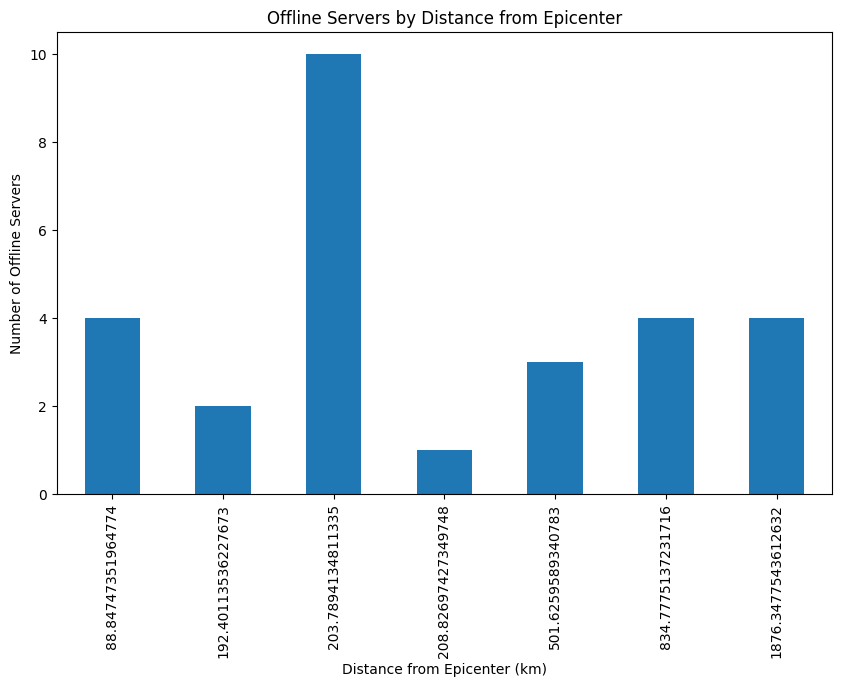

In [383]:
from geopy.distance import geodesic

# Earthquake epicenter coordinates
epicenter = (-7.492  , 108.174)

# Calculate distance for each server
offline_servers['distance_km'] = offline_servers.apply(lambda row: geodesic((row['latitude'], row['longitude']), epicenter).km, axis=1)

# Analyze offline rates by distance
offline_by_distance = offline_servers[offline_servers['Went_Offline']].groupby('distance_km').size()

# Plot the distribution of offline servers by distance
offline_by_distance.plot(kind='bar', figsize=(10, 6), title="Offline Servers by Distance from Epicenter")
plt.xlabel("Distance from Epicenter (km)")
plt.ylabel("Number of Offline Servers")
plt.show()


In [ ]:
# Create a map centered on Indonesia (or relevant area)
map_center = [df['latitude'].mean(), df['longitude'].mean()]
server_map = folium.Map(location=map_center, zoom_start=6)

# Add offline servers to the map
for _, row in offline_servers.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"NS_ID: {row['NS_ID']}<br>Last Seen: {row['LAST_SEEN']}",
        icon=folium.Icon(color='red', icon='times-circle', prefix='fa')
    ).add_to(server_map)

# Add online servers to the map
for _, row in online_servers.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"NS_ID: {row['NS_ID']}<br>Last Seen: {row['LAST_SEEN']}",
        icon=folium.Icon(color='green', icon='check-circle', prefix='fa')
    ).add_to(server_map)

# Save the map to an HTML file
server_map.save("server_status_map.html")
print("Map saved to 'server_status_map.html'")

# Display basic insights
total_offline = len(offline_servers)
total_online = len(online_servers)
print(f"Total Offline Servers (within 10 days): {total_offline}")
print(f"Total Online Servers: {total_online}")
